In [3]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from pylab import rcParams
rcParams['figure.figsize'] = 10,6

In [14]:
# нормальное распределение
norm_rv = stats.norm(loc=30, scale=5)

In [15]:
# выборка
samples = norm_rv.rvs(size=365)

In [16]:
samples[:30]

array([27.05881508, 28.13503053, 22.19704537, 31.31279927, 33.46948656,
       34.67446283, 27.52037707, 27.88749737, 31.85304679, 25.02619618,
       24.58080837, 31.48472376, 35.68180044, 32.37443352, 30.76478766,
       34.78480456, 33.49668632, 29.90331585, 28.95292146, 35.03743616,
       29.03952022, 27.47583946, 36.36047097, 34.29919574, 41.63410902,
       34.18760696, 32.95886609, 22.32437526, 33.57286624, 31.40762813])

In [17]:
# если нужно что бы не было дробной части в распределении
samples = np.trunc(samples)
samples[:30]


array([27., 28., 22., 31., 33., 34., 27., 27., 31., 25., 24., 31., 35.,
       32., 30., 34., 33., 29., 28., 35., 29., 27., 36., 34., 41., 34.,
       32., 22., 33., 31.])

29.523287671232875
4.927710867806401


/home/alekspy/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

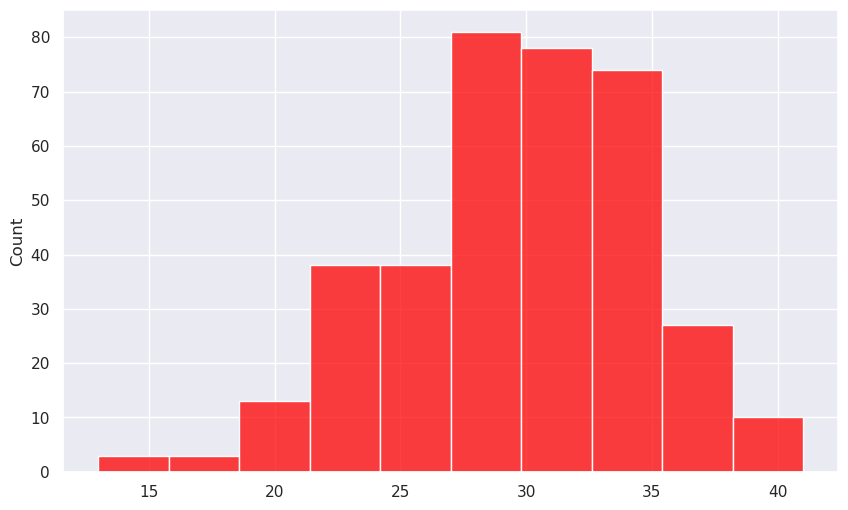

In [25]:
# выборочное  среднее и дисперсия
print(samples.mean())
print(samples.std())

# построение гистограммы
sns.histplot(samples, bins=10, color='red')




In [27]:
# распределение Пуассона
mu = 0.6
rv = stats.poisson(mu)
rv.stats()

(0.6, 0.6)

In [28]:
# распределение Бернулли
p = 0.4
rv = stats.bernoulli(p)
rv.stats()


(0.4, 0.24)

(array([6.10958904, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 3.89041096]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

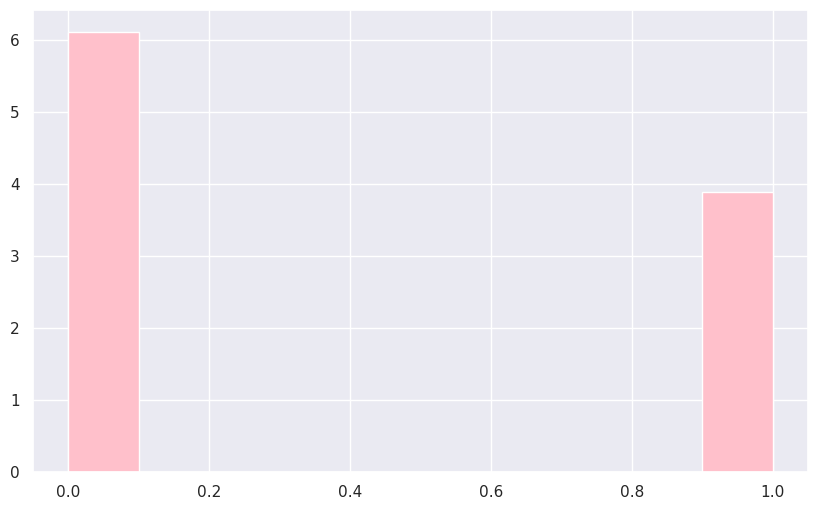

In [31]:
# создам 365 значение по распределению Бернулли
s = rv.rvs(size=365)
plt.hist(s, bins=10, color='pink', density=True)

In [32]:
# собственное распределение вероятности
elements = [1,2,3]
probs = [0.3, 0.5, 0.2]

np.random.choice(elements, size=10, p=probs)

array([2, 2, 2, 1, 2, 3, 1, 2, 1, 3])

In [33]:
myDistribution = stats.rv_discrete(
    name='myDistribution',
    values=([1,2,3,4,5], [0.2, 0.3, 0.3, 0.1, 0.1]) # [значения, вероятности]  
)
sample = myDistribution.rvs(size=20)

print(f"первые 10 значений: {sample[:10]}")


первые 10 значений: [3 2 1 2 3 2 3 5 3 5]


In [34]:
# функция плотности вероятности
norm_rv = stats.norm(loc=2, scale=0.5)

# cdf это 
norm_rv.cdf(3)


0.9772498680518208

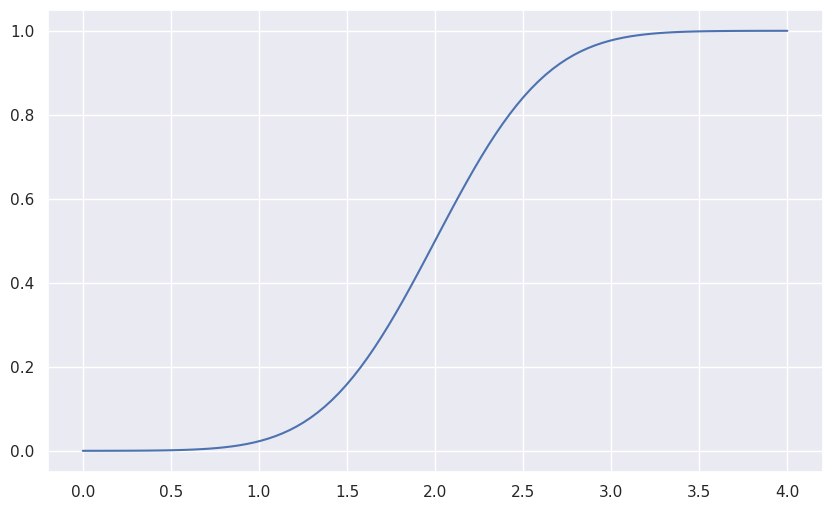

In [35]:
# визуализация всей функции cdf
x = np.linspace(0, 4, 100)
cdf = norm_rv.cdf(x)

plt.plot(x, cdf)
plt.show()


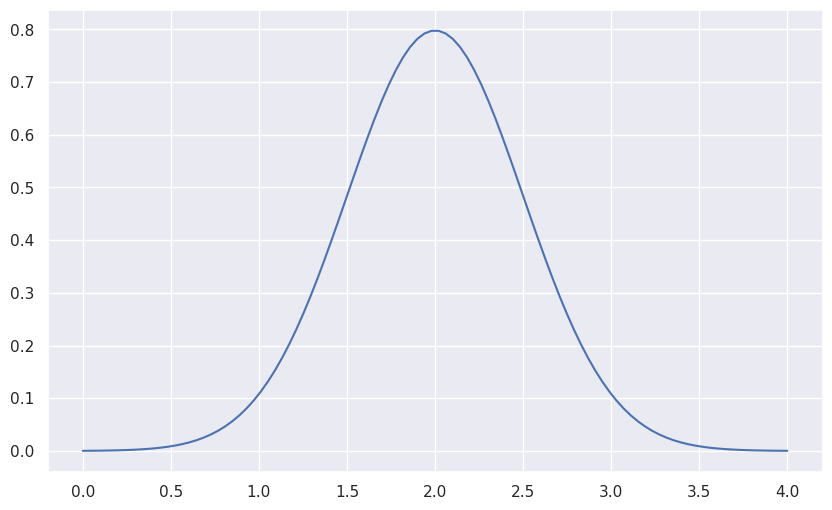

2.822426813475736

In [36]:
pdf = norm_rv.pdf(x)

plt.plot(x, pdf)
plt.show()

# обратная функция распределения
norm_rv.ppf(0.95)

# визуализация обратной функции распределения



In [2]:
# центральная предельная теорема с использованием питона
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from pylab import rcParams
rcParams['figure.figsize'] = 10,6

In [3]:
# задам экспоненциальное распределение
exp_rv = stats.expon(loc=10, scale=1.5)

In [4]:
exp_data = exp_rv.rvs(size=1000) # выборка из 1000

/home/alekspy/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

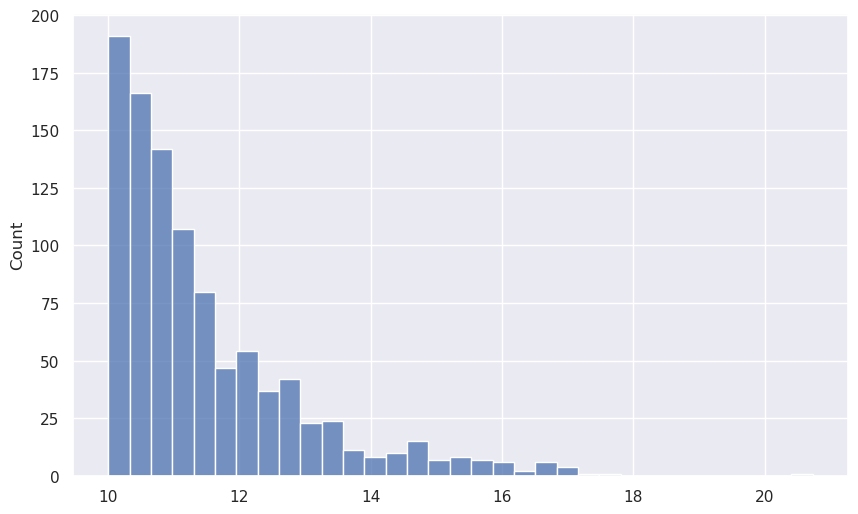

In [5]:
data = exp_data
sns.histplot(data=data)

/home/alekspy/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

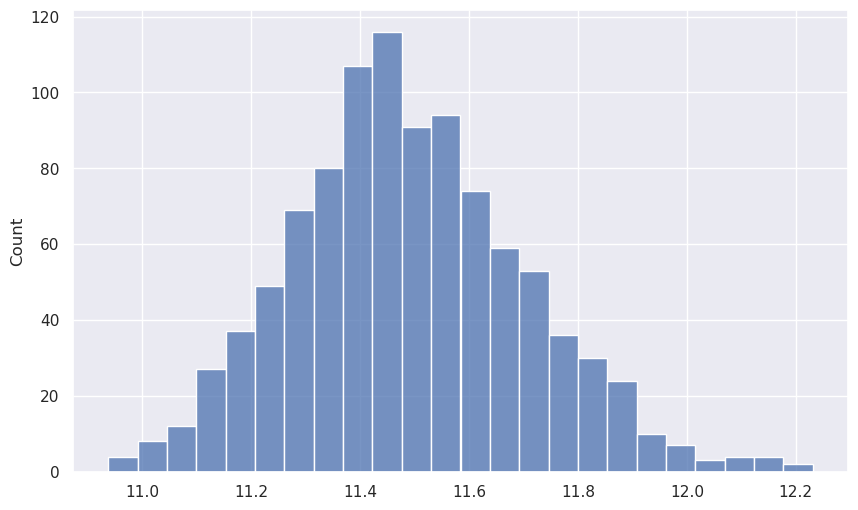

In [7]:
# выберем несоклько данных, усредним и построим новое распределение
mList=[];
for kk in range(1000):
    exp_data = exp_rv.rvs(size=50)
    mList.append(exp_data.mean())

sns.histplot(x=mList)